In [1]:
try:
    import pgmuvi
except (ImportError, ModuleNotFoundError):
    # %pip -q install pgmuvi
    !pip install -q git+https://github.com/ICSM/pgmuvi.git@copilot/implement-acf-method-lightcurve
    import pgmuvi

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 13.5 MB/s eta 0:00:00


## Quasi-periodic signals and deterministic mean functions

This notebook addresses two referee-requested use cases beyond a simple sine-wave demonstration:

1. a non-strictly-periodic signal with highly uneven sampling, and
2. a GP coupled to a deterministic non-zero mean function.

The examples use the model strings already exposed by `Lightcurve.fit()`:

- `model="1DQuasiPeriodic"`
- `model="1DPeriodicStochastic"`
- `model="1DLinearQuasiPeriodic"`

The mock data in the first example are generated manually because the current `synthetic.py` module provides sinusoidal and multi-sinusoidal generators, but not a true quasi-periodic GP-draw generator.

In [2]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

from pgmuvi.lightcurve import Lightcurve

SEED = 11
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DTYPE = torch.float32
DEVICE = torch.device("cpu")

## Example 1: a quasi-periodic signal with highly uneven sampling

This example is designed to mimic a realistic ground-based observing pattern. The sampling is highly uneven because the observations are grouped into observing seasons separated by long gaps.

The underlying signal is not a strict sine wave. It has an approximate period $P$, but the amplitude and phase evolve slowly with time. This is the kind of case for which a quasi-periodic covariance is more appropriate than a strictly periodic model.

In [3]:
# Quasi-periodic mock-data configuration

TRUE_PERIOD = 320.0
T_SPAN = 6.0 * TRUE_PERIOD
N_SEASONS = 6
POINTS_PER_SEASON = [14, 22, 9, 28, 16, 24]
SEASON_LENGTH = 70.0
NOISE_SIGMA = 0.12

rng = np.random.default_rng(SEED)

season_starts = np.linspace(0.0, T_SPAN - SEASON_LENGTH, N_SEASONS)
time_blocks = []

for start, n_points in zip(season_starts, POINTS_PER_SEASON):
    time_blocks.append(start + rng.uniform(0.0, SEASON_LENGTH, n_points))

time_qp = np.sort(np.concatenate(time_blocks))

# Slowly varying amplitude and phase: not a strictly periodic sinusoid.
amplitude_envelope = 1.0 + 0.35 * np.sin(2.0 * np.pi * time_qp / (3.5 * TRUE_PERIOD))
phase_wander = 0.45 * np.sin(2.0 * np.pi * time_qp / (4.2 * TRUE_PERIOD))

signal_qp = amplitude_envelope * np.sin(
    2.0 * np.pi * time_qp / TRUE_PERIOD + phase_wander
)

flux_qp = signal_qp + rng.normal(0.0, NOISE_SIGMA, size=time_qp.size)
fluxerr_qp = np.full_like(flux_qp, NOISE_SIGMA)

lc_qp = Lightcurve(
    torch.as_tensor(time_qp, dtype=DTYPE),
    torch.as_tensor(flux_qp, dtype=DTYPE),
    yerr=torch.as_tensor(fluxerr_qp, dtype=DTYPE),
)

print(lc_qp)
print("Number of observations:", lc_qp.ydata.numel())
print("Time span:", float(lc_qp.xdata.max() - lc_qp.xdata.min()))
print("True injected approximate period:", TRUE_PERIOD)

Lightcurve()
Number of observations: 113
Time span: 1917.907958984375
True injected approximate period: 320.0


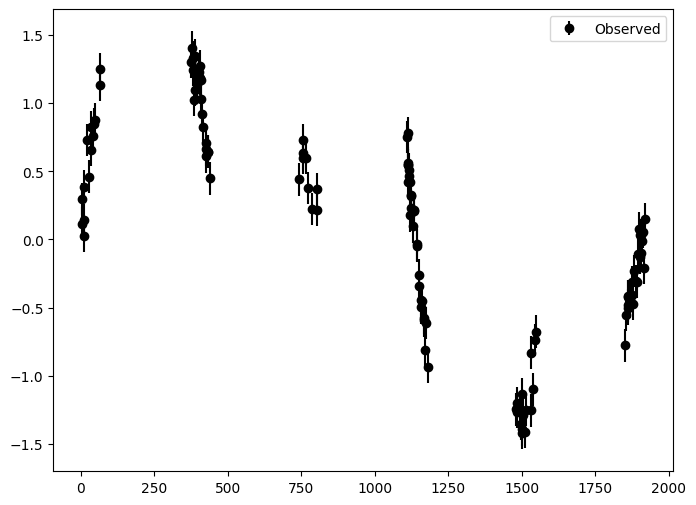

In [4]:
_ = lc_qp.plot()

### Interpretation of the observed variability

The light curve shows clear structured variability, but it is not well described by a simple strictly periodic sinusoid over the observed baseline.

Several features are consistent with quasi-periodicity:
- The spacing between peaks is roughly regular, suggesting an underlying characteristic timescale.
- The amplitudes of successive cycles vary significantly.
- The phase of the oscillations drifts over time.

This is therefore a realistic case where a strictly periodic model is inadequate, and a quasi-periodic covariance is more appropriate.

Before fitting the GP, we inspect the sampling and the Lomb--Scargle periodogram. This is useful because the sampling itself limits which periods can be interpreted reliably.

The Lomb--Scargle periodogram is not the final model here. It is used as a diagnostic and, where appropriate, as an initialization tool for GP fitting.

In [5]:
sampling_qp = lc_qp.compute_sampling_metrics()

for key, value in sampling_qp.items():
  print(f"{key}: {value}")

n_points: 113
baseline: 1917.907958984375
max_gap: 309.4351806640625
max_gap_fraction: 0.1613399533666482
median_cadence: 2.5836181640625
mean_cadence: 17.124177932739258
cadence_std: 62.396888732910156
nyquist_period: 5.167236328125
nyquist_frequency: 0.19352704937396645
longest_detectable_period: 958.9539794921875
duty_cycle: 0.15222255644304408
sampling_uniformity: 0.0
median_snr: 4.778744220733643
mean_snr: 5.392579078674316
fraction_snr_gt_3: 0.7256637168141593
fraction_snr_gt_5: 0.4690265486725664


Lomb--Scargle peak periods: tensor([314.4112])
Significance flags: tensor([True])


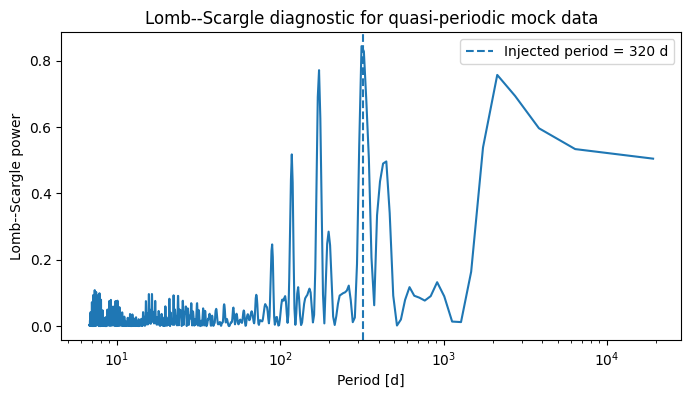

In [6]:
peaks_qp, peak_flags_qp, freq_qp, power_qp = lc_qp.fit_LS(
    freq_only=False,
    return_full=True,
)

periods_qp = 1.0 / peaks_qp

print("Lomb--Scargle peak periods:", periods_qp)
print("Significance flags:", peak_flags_qp)

fig, ax = plt.subplots(figsize=(8, 4))

# Convert frequency grid to period
period = 1.0 / freq_qp

# Sort by period for plotting
idx = np.argsort(period)
period_sorted = period[idx]
power_sorted = power_qp[idx]

# Plot Lomb--Scargle power as a function of period
# plt.figure(figsize=(7, 4.5))
ax.plot(period_sorted, power_sorted)
ax.axvline(TRUE_PERIOD, linestyle="--", label=f"Injected period = {TRUE_PERIOD:.0f} d")
ax.set_xscale("log")
ax.set_xlabel("Period [d]")
ax.set_ylabel("Lomb--Scargle power")
ax.set_title(f"Lomb--Scargle diagnostic for quasi-periodic mock data")
ax.legend()
plt.show()

### Interpretation of the Lomb--Scargle diagnostic

The Lomb--Scargle periodogram identifies a dominant peak near the injected period.

However, several important limitations are evident:

- The peak is not perfectly sharp, reflecting the non-strict periodicity of the signal.
- Additional structure appears at longer periods, partly driven by the uneven sampling and seasonal gaps.

Despite these limitations, the Lomb--Scargle result provides a useful estimate of the characteristic timescale, which can be used to initialize the GP model.

While the Lomb--Scargle periodogram provides a useful estimate of the characteristic timescale, it is fundamentally a frequency-domain diagnostic that assumes strict periodicity. In cases where the signal is only approximately periodic, it is more informative to examine the correlation structure directly in the time domain.

We therefore turn to the autocorrelation function (ACF), which provides a more direct and robust diagnostic of quasi-periodic behavior.

### Data-driven ACF of the unevenly sampled light curve

The autocorrelation function provides a direct time-domain diagnostic of quasi-periodicity. For a strictly periodic signal, the correlation pattern would persist without decay. For a quasi-periodic signal, the ACF should show oscillatory structure but with reduced coherence at larger lags.

Here we first estimate the ACF directly from the data using the pairwise lag-binned estimator implemented in `Lightcurve.acf(method="data")`, which is appropriate for unevenly sampled observations. In this unevenly sampled example, the data-driven ACF is noisy and should not be interpreted as a smooth estimate of the underlying covariance. Nevertheless, it shows correlation structure near the injected timescale and illustrates why a model-based ACF is useful.

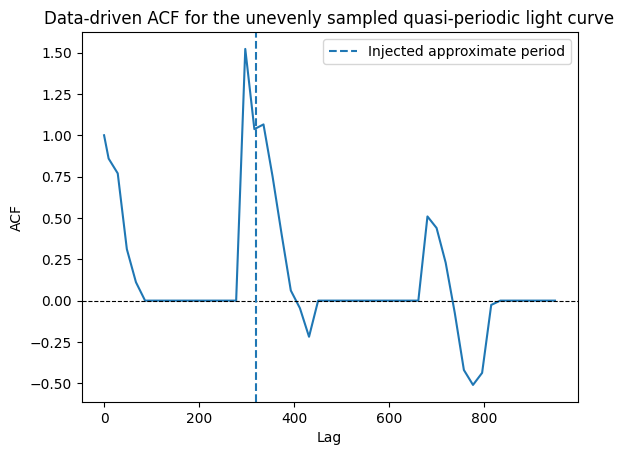

In [7]:
acf_qp_data = lc_qp.acf(
    method="data",
    n_lags=50,
    max_lag=sampling_qp["longest_detectable_period"],
)

ax = lc_qp.plot_acf(
    method="data",
    n_lags=50,
    max_lag=sampling_qp["longest_detectable_period"],
)

ax.axvline(TRUE_PERIOD, linestyle="--", label="Injected approximate period")
ax.set_title("Data-driven ACF for the unevenly sampled quasi-periodic light curve")
ax.legend()

plt.show()

### GP fit with a quasi-periodic kernel

We now fit the same light curve using the existing `1DQuasiPeriodic` model. This model is already exposed through `Lightcurve.fit()` and is intended for signals that retain an approximate recurrence timescale but are not exactly periodic.

mean_module.constant: -0.006344318389892578
covar_module.outputscale: 0.6931471824645996
covar_module.base_kernel.kernels.0.lengthscale: tensor([[0.6931]])
covar_module.base_kernel.kernels.0.period_length: tensor([[320.]])
covar_module.base_kernel.kernels.1.lengthscale: tensor([[1600.]])


100%|██████████| 500/500 [00:04<00:00, 118.61it/s]
/usr/local/lib/python3.12/dist-packages/gpytorch/likelihoods/gaussian_likelihood.py:350: GPInputWarning: You have passed data through a FixedNoiseGaussianLikelihood that did not match the size of the fixed noise, *and* you did not specify noise. This is treated as a no-op.
  warnings.warn(


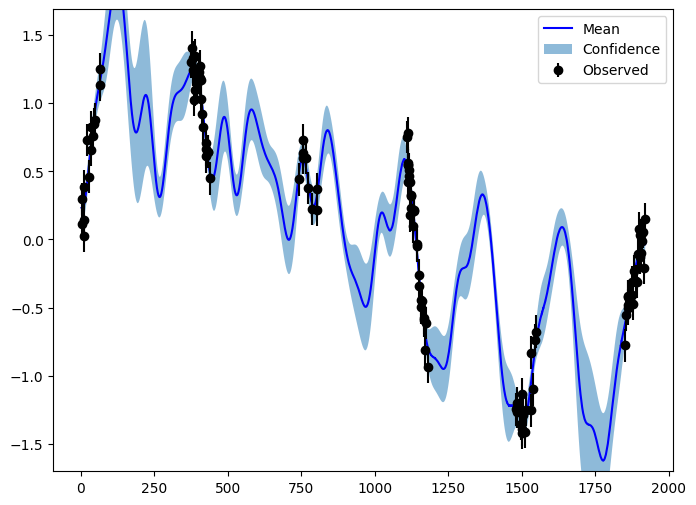

In [8]:
_ = lc_qp.fit(
    model="1DQuasiPeriodic",
    period=TRUE_PERIOD,
    training_iter=500,
    lr=0.05,
    max_samples=None,
)

_ = lc_qp.plot()

### Interpretation of the quasi-periodic GP fit

The quasi-periodic GP model reproduces the main features of the data while allowing the fitted curve to evolve from cycle to cycle.

Key points:

- The model captures the approximate recurrence timescale of the variability.
- The predictive uncertainty increases in the seasonal gaps, reflecting the lack of observational constraints.

This demonstrates the advantage of GP-based modeling over strictly periodic methods for irregular and evolving signals.

The structure described above can be quantified more precisely using the autocorrelation function implied by the fitted GP model.

In [9]:
print("Fitted model class:", type(lc_qp.model).__name__)

print("\nFitted model parameters:")
for name, parameter in lc_qp.model.named_parameters():
    print(name, parameter.detach().cpu().numpy())

Fitted model class: QuasiPeriodicGPModel

Fitted model parameters:
mean_module.raw_constant 0.22214693
covar_module.raw_outputscale 1.8415475
covar_module.base_kernel.kernels.0.raw_lengthscale [[1.1015086]]
covar_module.base_kernel.kernels.0.raw_period_length [[263.0803]]
covar_module.base_kernel.kernels.1.raw_lengthscale [[1227.0491]]


### From data ACF to GP-implied ACF

The data-driven ACF provides a noisy estimate of the correlation structure in the observations. The fitted GP model defines a smooth, parametric version of this same quantity through its covariance kernel.

We therefore expect the GP-implied ACF to reproduce the main features of the data-driven ACF, while suppressing noise and sampling artifacts. The comparison between the two provides a consistency check on the model. In particular, we expect the oscillation timescale and the decay of the correlation envelope with lag to be consistent between the two.

### GP-implied ACF for the quasi-periodic model

The fitted quasi-periodic GP also defines an autocorrelation function through its covariance kernel. This is cleaner than the data-driven ACF because it is evaluated from the fitted model rather than from noisy, irregularly sampled pairs.

The key quantity is not only the recurrence timescale, but also how rapidly the correlation envelope decays with lag. A decaying oscillatory ACF reflects finite coherence in the signal, consistent with quasi-periodic variability.

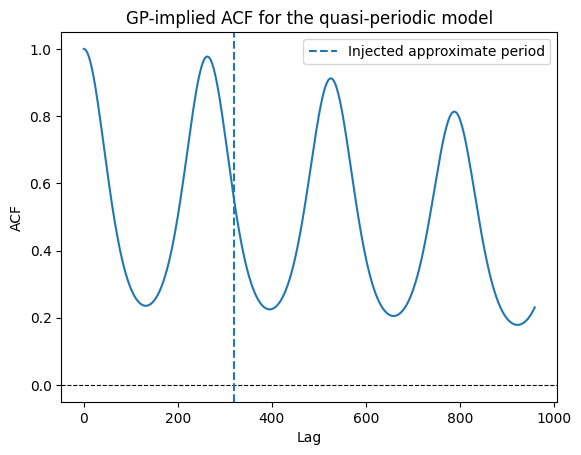

In [10]:
acf_qp_gp = lc_qp.acf(
    method="gp",
    n_lags=500,
    max_lag=sampling_qp["longest_detectable_period"],
)

ax = lc_qp.plot_acf(
    method="gp",
    n_lags=500,
    max_lag=sampling_qp["longest_detectable_period"],
)

ax.axvline(TRUE_PERIOD, linestyle="--", label="Injected approximate period")
ax.set_title("GP-implied ACF for the quasi-periodic model")
ax.legend()

plt.show()

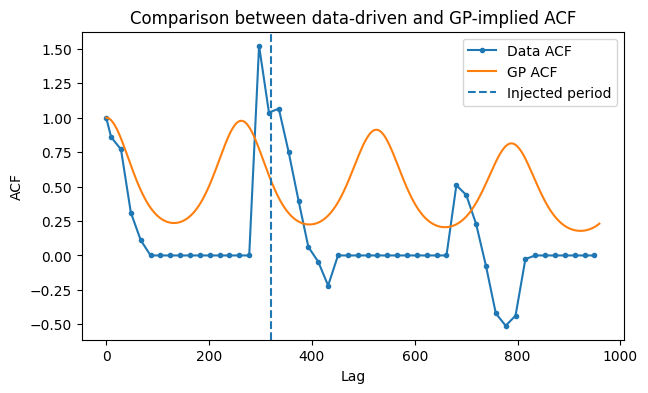

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))

acf_data = lc_qp.acf(
    method="data",
    n_lags=50,
    max_lag=sampling_qp["longest_detectable_period"],
)

acf_gp = lc_qp.acf(
    method="gp",
    n_lags=500,
    max_lag=sampling_qp["longest_detectable_period"],
)

ax.plot(acf_data.lag, acf_data.acf, marker='.', label="Data ACF")
ax.plot(acf_gp.lag, acf_gp.acf, label="GP ACF")

ax.axvline(TRUE_PERIOD, linestyle="--", label="Injected period")
ax.set_xlabel("Lag")
ax.set_ylabel("ACF")
ax.set_title("Comparison between data-driven and GP-implied ACF")
ax.legend()

plt.show()

The comparison should be interpreted qualitatively rather than point-by-point. The data-driven ACF is noisy and strongly affected by the uneven sampling and lag-bin occupancy, producing sharp features and extended regions near zero. The GP-implied ACF is smoother because it is evaluated from the fitted covariance model.

The useful agreement is that both diagnostics identify correlation structure on approximately the injected timescale. The detailed shapes are not expected to match exactly: the data-driven ACF is an empirical, binned estimate, whereas the GP ACF is the model-implied covariance structure.

### Alternative model: quasi-periodic plus stochastic variability

The uploaded code base also exposes `model="1DPeriodicStochastic"`. This model adds a stochastic component to the quasi-periodic covariance. It is useful when the data show a recurrent timescale together with extra correlated variability that is not well described by a single quasi-periodic component.

mean_module.constant: -0.006344318389892578
covar_module.kernels.0.outputscale: 0.6931471824645996
covar_module.kernels.0.base_kernel.kernels.0.lengthscale: tensor([[0.6931]])
covar_module.kernels.0.base_kernel.kernels.0.period_length: tensor([[320.]])
covar_module.kernels.0.base_kernel.kernels.1.lengthscale: tensor([[1600.]])
covar_module.kernels.1.outputscale: 0.6931471824645996
covar_module.kernels.1.base_kernel.lengthscale: tensor([[320.]])


100%|██████████| 500/500 [00:04<00:00, 110.04it/s]


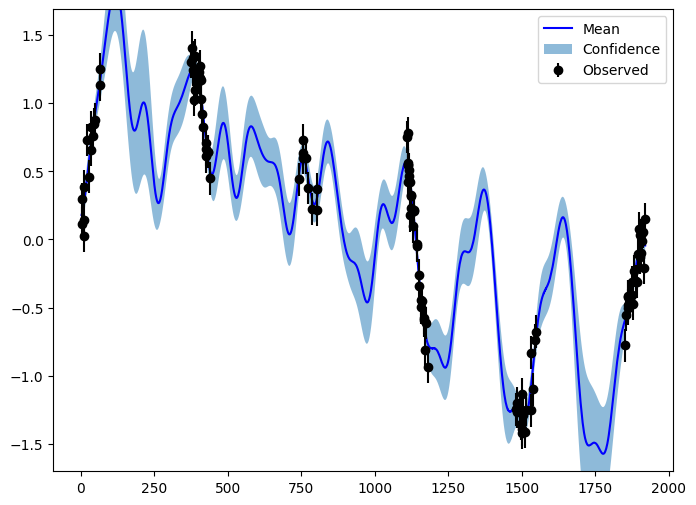

Fitted model class: PeriodicPlusStochasticGPModel

Fitted model parameters:
mean_module.raw_constant 0.10415806
covar_module.kernels.0.raw_outputscale 1.2639463
covar_module.kernels.0.base_kernel.kernels.0.raw_lengthscale [[1.2414271]]
covar_module.kernels.0.base_kernel.kernels.0.raw_period_length [[266.94742]]
covar_module.kernels.0.base_kernel.kernels.1.raw_lengthscale [[1219.5121]]
covar_module.kernels.1.raw_outputscale -6.4900227
covar_module.kernels.1.base_kernel.raw_lengthscale [[241.82664]]


In [12]:
lc_qp_stoch = Lightcurve(
    torch.as_tensor(time_qp, dtype=DTYPE),
    torch.as_tensor(flux_qp, dtype=DTYPE),
    yerr=torch.as_tensor(fluxerr_qp, dtype=DTYPE),
)

_ = lc_qp_stoch.fit(
    model="1DPeriodicStochastic",
    period=TRUE_PERIOD,
    training_iter=500,
    lr=0.05,
    max_samples=None,
)

_ = lc_qp_stoch.plot()

print("Fitted model class:", type(lc_qp_stoch.model).__name__)

print("\nFitted model parameters:")
for name, parameter in lc_qp_stoch.model.named_parameters():
    print(name, parameter.detach().cpu().numpy())

### Interpretation of the periodic plus stochastic GP fit

This model extends the quasi-periodic description by adding an additional stochastic component.

Relative to the pure quasi-periodic model, this model is designed to:
- The fit can accommodate extra correlated variability that is not phase-locked to the main oscillation.
- The additional stochastic component gives the model flexibility to absorb residual correlated structure that is not tied to the main recurrence timescale.
- The long-timescale structure remains governed by the quasi-periodic component.

This type of model is useful when the data show a dominant timescale but also contain additional variability that cannot be described by a single quasi-periodic process.

### GP-implied ACF for the periodic plus stochastic model

The periodic-plus-stochastic model contains both a recurrent component and an additional stochastic component. Its ACF is therefore useful for checking whether the model is describing a coherent recurrence plus extra correlated variability, rather than forcing all structure into a single quasi-periodic component.

In this particular mock example, the GP-implied ACF remains dominated by the recurrent quasi-periodic component, so the stochastic component does not qualitatively change the large-scale correlation structure.

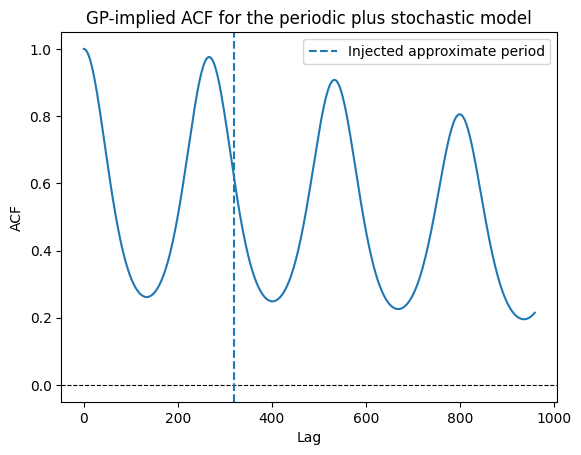

In [13]:
acf_qp_stoch_gp = lc_qp_stoch.acf(
    method="gp",
    n_lags=500,
    max_lag=sampling_qp["longest_detectable_period"],
)

ax = lc_qp_stoch.plot_acf(
    method="gp",
    n_lags=500,
    max_lag=sampling_qp["longest_detectable_period"],
)

ax.axvline(TRUE_PERIOD, linestyle="--", label="Injected approximate period")
ax.set_title("GP-implied ACF for the periodic plus stochastic model")
ax.legend()

plt.show()

## Example 2: a quasi-periodic GP with a deterministic linear mean function

The referee also asked whether the GP can be coupled to a deterministic non-zero mean function. The uploaded code base already exposes this through `model="1DLinearQuasiPeriodic"`.

In this example, the data contain both:

1. a deterministic linear trend, and
2. a quasi-periodic residual signal.

The linear mean is not meant to replace the GP. Instead, it models a smooth deterministic component while the covariance models the correlated quasi-periodic residual variability.

In [34]:
# Mock data with both a deterministic linear trend and quasi-periodic residual structure.

TRUE_PERIOD_TREND = 280.0
TRUE_INTERCEPT = 0.7
TRUE_SLOPE = 4.0e-4
T_SPAN_TREND = 5.5 * TRUE_PERIOD_TREND
NOISE_SIGMA_TREND = 0.10

rng = np.random.default_rng(SEED + 1)

season_starts = np.linspace(0.0, T_SPAN_TREND - SEASON_LENGTH, N_SEASONS)
time_blocks = []

for start, n_points in zip(season_starts, POINTS_PER_SEASON):
    time_blocks.append(start + rng.uniform(0.0, SEASON_LENGTH, n_points))

time_trend = np.sort(np.concatenate(time_blocks))

deterministic_trend = TRUE_INTERCEPT + TRUE_SLOPE * time_trend

# amplitude_envelope = 0.7 + 0.25 * np.sin(
#     2.0 * np.pi * time_trend / (3.0 * TRUE_PERIOD_TREND)
# )
amplitude_envelope = 0.4 + 0.25 * np.sin(
    2.0 * np.pi * time_trend / (3.0 * TRUE_PERIOD_TREND)
)
phase_wander = 0.35 * np.sin(
    2.0 * np.pi * time_trend / (4.0 * TRUE_PERIOD_TREND)
)

qp_residual = amplitude_envelope * np.sin(
    2.0 * np.pi * time_trend / TRUE_PERIOD_TREND + phase_wander
)

flux_trend = deterministic_trend + qp_residual
flux_trend = flux_trend + rng.normal(0.0, NOISE_SIGMA_TREND, size=time_trend.size)

fluxerr_trend = np.full_like(flux_trend, NOISE_SIGMA_TREND)

lc_linear_qp = Lightcurve(
    torch.as_tensor(time_trend, dtype=DTYPE),
    torch.as_tensor(flux_trend, dtype=DTYPE),
    yerr=torch.as_tensor(fluxerr_trend, dtype=DTYPE),
)

print(lc_linear_qp)
print("Injected approximate period:", TRUE_PERIOD_TREND)
print("Injected linear intercept:", TRUE_INTERCEPT)
print("Injected linear slope:", TRUE_SLOPE)

Lightcurve()
Injected approximate period: 280.0
Injected linear intercept: 0.7
Injected linear slope: 0.0004


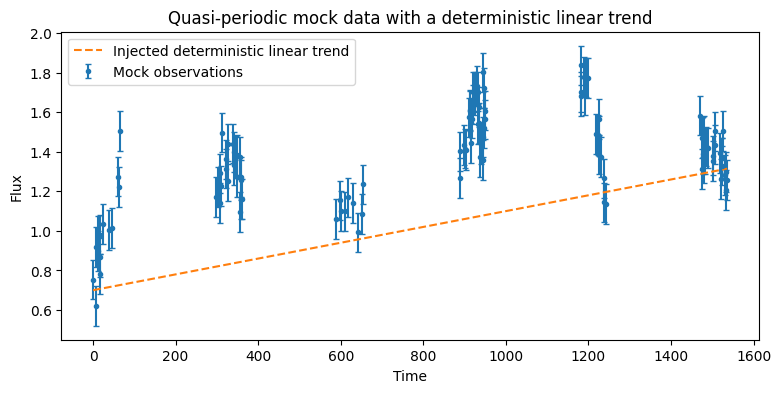

In [35]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.errorbar(
    time_trend,
    flux_trend,
    yerr=fluxerr_trend,
    fmt=".",
    capsize=2,
    label="Mock observations",
)

ax.plot(
    time_trend,
    deterministic_trend,
    linestyle="--",
    label="Injected deterministic linear trend",
)

ax.set_xlabel("Time")
ax.set_ylabel("Flux")
ax.set_title("Quasi-periodic mock data with a deterministic linear trend")
ax.legend()

plt.show()

### Interpretation of the mock data with a deterministic trend

This dataset contains two distinct components:

- A deterministic linear trend, visible as a slow increase in the baseline flux beneath the larger quasi-periodic excursions.
- A quasi-periodic residual signal superimposed on that trend.

The key point is that the oscillatory behavior is not centered around a constant mean. Instead, the mean itself evolves with time.

A zero-mean GP would be forced to absorb both the trend and the variability into the covariance, which is not physically appropriate. This motivates the use of a model with an explicit deterministic mean function.

In [36]:
peaks_trend, peak_flags_trend, freq_trend, power_trend = lc_linear_qp.fit_LS(
    freq_only=False,
    return_full=True,
)

periods_trend = 1.0 / peaks_trend

print("Lomb--Scargle peak periods:", periods_trend)
print("Significance flags:", peak_flags_trend)

Lomb--Scargle peak periods: tensor([269.4329])
Significance flags: tensor([True])


### Interpretation of the Lomb--Scargle result with a trend present

The Lomb--Scargle periodogram still identifies the dominant quasi-periodic timescale.

However, the presence of a linear trend can in general affect period searches:
- Power can leak to longer timescales due to the non-stationary mean.
- The peak location may be slightly biased relative to the injected period.
- The method does not explicitly separate deterministic and stochastic components.

This reinforces the need for a model that explicitly accounts for the mean function.

### Data-driven ACF before accounting for the deterministic trend

This ACF is computed directly from the observed fluxes. Because the light curve contains a deterministic linear trend, the raw data-driven ACF mixes two effects: long-timescale correlation from the trend and quasi-periodic correlation from the residual variability.

This is useful as a diagnostic, but it is not yet a clean estimate of the quasi-periodic residual structure.

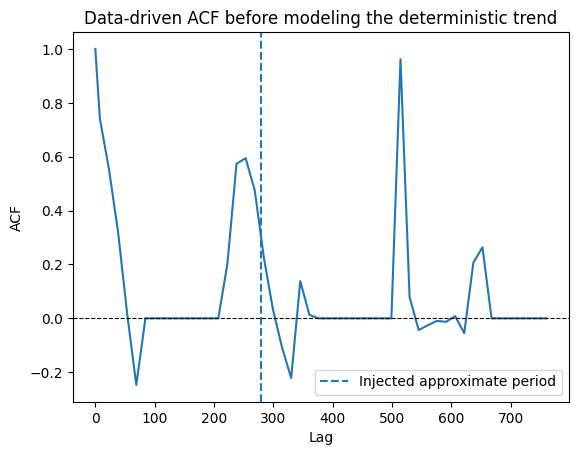

In [37]:
sampling_trend = lc_linear_qp.compute_sampling_metrics()

acf_trend_data = lc_linear_qp.acf(
    method="data",
    n_lags=50,
    max_lag=sampling_trend["longest_detectable_period"],
)

ax = lc_linear_qp.plot_acf(
    method="data",
    n_lags=50,
    max_lag=sampling_trend["longest_detectable_period"],
)

ax.axvline(TRUE_PERIOD_TREND, linestyle="--", label="Injected approximate period")
ax.set_title("Data-driven ACF before modeling the deterministic trend")
ax.legend()

plt.show()

### Fit with `1DLinearQuasiPeriodic`

The model below combines a linear mean function with a quasi-periodic covariance. This directly addresses the referee's request for a GP coupled to a deterministic model.

mean_module.weights: tensor([[0.2462]])
mean_module.bias: tensor([0.4839])
covar_module.outputscale: 0.6931471824645996
covar_module.base_kernel.kernels.0.lengthscale: tensor([[0.6931]])
covar_module.base_kernel.kernels.0.period_length: tensor([[280.]])
covar_module.base_kernel.kernels.1.lengthscale: tensor([[1400.]])


100%|██████████| 500/500 [00:03<00:00, 158.07it/s]


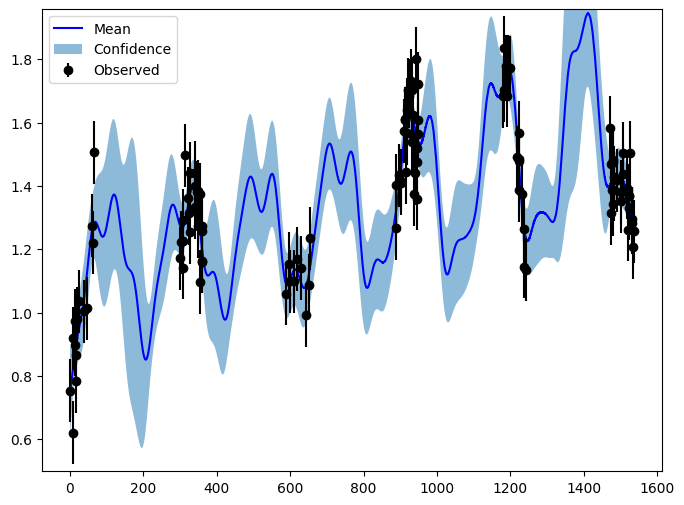

Fitted model class: LinearMeanQuasiPeriodicGPModel

Fitted model parameters:
mean_module.weights [[0.00063221]]
mean_module.bias [0.54533035]
covar_module.raw_outputscale 0.584826
covar_module.base_kernel.kernels.0.raw_lengthscale [[0.5894033]]
covar_module.base_kernel.kernels.0.raw_period_length [[218.08766]]
covar_module.base_kernel.kernels.1.raw_lengthscale [[1089.6273]]


In [38]:
_ = lc_linear_qp.fit(
    model="1DLinearQuasiPeriodic",
    period=TRUE_PERIOD_TREND,
    training_iter=500,
    lr=0.05,
    max_samples=None,
)

_ = lc_linear_qp.plot()

print("Fitted model class:", type(lc_linear_qp.model).__name__)

print("\nFitted model parameters:")
for name, parameter in lc_linear_qp.model.named_parameters():
    print(name, parameter.detach().cpu().numpy())

The printed parameters include the parameters of the deterministic mean module and the quasi-periodic covariance module. The exact parameter names are those used internally by GPyTorch and the `pgmuvi` model class.

For interpretation, the important point is structural: this is not a zero-mean GP forced to absorb everything into the covariance. The model contains an explicit linear mean function, while the GP covariance describes the correlated quasi-periodic departures around that mean.

### Interpretation of the GP with a linear mean function

This model separates the deterministic and stochastic components of the variability.

The results show that:

- The linear mean function captures the global trend in the data.
- The quasi-periodic covariance models the oscillatory residual structure.
- The explicit mean function gives the model a separate component for the long-term trend, rather than requiring the covariance alone to represent both trend and residual variability.

This decomposition is physically meaningful: the mean function represents a smooth long-term evolution, while the covariance describes correlated variability around that evolution.

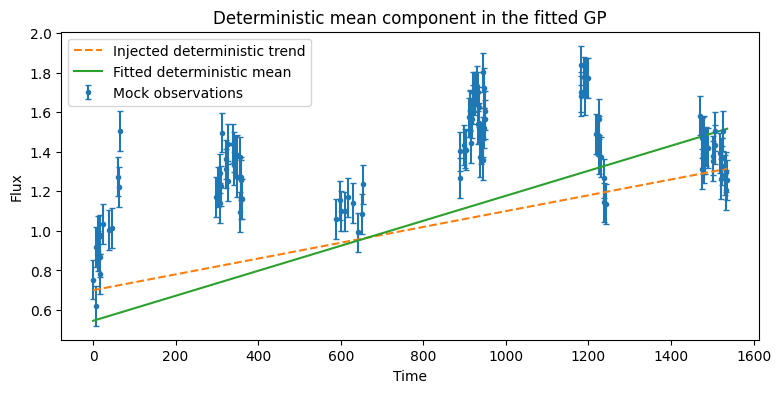

In [39]:
# Evaluate the fitted deterministic mean function on a fine grid.
# This uses the fitted model's own mean_module rather than reimplementing a trend fit.

x_fine_raw = torch.linspace(
    float(lc_linear_qp.xdata.min()),
    float(lc_linear_qp.xdata.max()),
    1000,
    dtype=DTYPE,
)

if lc_linear_qp.xtransform is None:
    x_fine_model = x_fine_raw
else:
    x_fine_model = lc_linear_qp.xtransform.transform(x_fine_raw)

lc_linear_qp.model.eval()
lc_linear_qp.likelihood.eval()

with torch.no_grad():
    fitted_mean = lc_linear_qp.model.mean_module(x_fine_model).detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(9, 4))

ax.errorbar(
    time_trend,
    flux_trend,
    yerr=fluxerr_trend,
    fmt=".",
    capsize=2,
    label="Mock observations",
)

ax.plot(
    time_trend,
    deterministic_trend,
    linestyle="--",
    label="Injected deterministic trend",
)

ax.plot(
    x_fine_raw.detach().cpu().numpy(),
    fitted_mean,
    label="Fitted deterministic mean",
)

ax.set_xlabel("Time")
ax.set_ylabel("Flux")
ax.set_title("Deterministic mean component in the fitted GP")
ax.legend()

plt.show()

### Comparison between injected and recovered deterministic trend

This plot compares the injected deterministic trend with the linear mean function recovered by the GP model.

The fitted mean captures the overall upward trend and is in reasonable agreement with the injected deterministic component across the observed time span. Small differences remain, and the recovered mean does not match the injected trend exactly, particularly in normalization and slope.

This reflects the fact that the deterministic trend is still modest compared with the quasi-periodic variability, and the data are unevenly sampled. As a result, some degeneracy between the mean function and the covariance structure persists.

The result should therefore be interpreted as a demonstration that `pgmuvi` can include and meaningfully constrain a non-zero deterministic mean function, while acknowledging that some bias in the recovered parameters can remain in realistic observational conditions.

### GP-implied ACF after fitting the deterministic mean

After fitting `1DLinearQuasiPeriodic`, the deterministic linear mean is represented explicitly by the mean function, while the covariance describes the correlated residual variability. The GP-implied ACF therefore corresponds to the quasi-periodic stochastic component rather than to the full raw light curve.

This is the most relevant ACF for interpreting finite coherence in the residual variability.

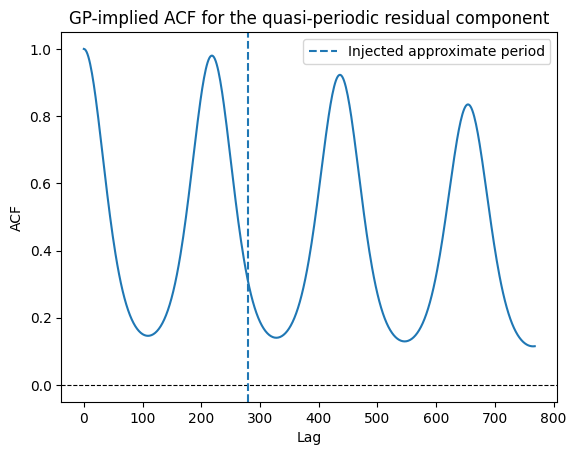

In [33]:
acf_linear_qp_gp = lc_linear_qp.acf(
    method="gp",
    n_lags=500,
    max_lag=sampling_trend["longest_detectable_period"],
)

ax = lc_linear_qp.plot_acf(
    method="gp",
    n_lags=500,
    max_lag=sampling_trend["longest_detectable_period"],
)

ax.axvline(TRUE_PERIOD_TREND, linestyle="--", label="Injected approximate period")
ax.set_title("GP-implied ACF for the quasi-periodic residual component")
ax.legend()

plt.show()

## Summary

This notebook demonstrates two applications of `pgmuvi`.

First, `pgmuvi` can be applied to non-strictly-periodic variability by using the already available quasi-periodic model family. The mock data in Example 1 have an approximate period, evolving amplitude, evolving phase, and highly uneven seasonal sampling.

Second, `pgmuvi` can fit a GP together with a deterministic non-zero mean function. Example 2 uses `model="1DLinearQuasiPeriodic"`, where the linear mean captures the deterministic trend and the quasi-periodic covariance captures the correlated residual variability.

These examples do not require new GP classes. They use model strings and workflows already exposed through the current `Lightcurve.fit()` interface.